# MSIN0097 Individual Coursework - Telco Customer Churn

This notebook is the primary project workflow (notebook-first).
It covers problem framing, EDA, preprocessing, modeling, evaluation, and artifact export.


## 1) Problem Framing
- Dataset: Kaggle Telco Customer Churn
- Task: Binary classification (predict `Churn`)
- Primary metric: F1 score (class-imbalance aware)
- Secondary metrics: ROC-AUC, Precision, Recall, Accuracy
- Split strategy: Stratified 60/20/20 (train/validation/test)


In [1]:
# Core imports
from pathlib import Path
import json

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mosapabdelghany/telcom-customer-churn-dataset")

print("Path to dataset files:", path)


100%|██████████| 172k/172k [00:00<00:00, 1.03MB/s]

Extracting files...
Path to dataset files: /Users/chenliqiang/.cache/kagglehub/datasets/mosapabdelghany/telcom-customer-churn-dataset/versions/1


In [3]:
# Locate CSV inside downloaded folder
dataset_dir = Path(path)
csv_files = sorted(dataset_dir.glob('*.csv'))
print('CSV files found:', [f.name for f in csv_files])
if not csv_files:
    raise FileNotFoundError('No CSV files found in downloaded dataset path.')
csv_path = csv_files[0]
print('Using CSV:', csv_path)


CSV files found: ['Telco_Cusomer_Churn.csv']
Using CSV: /Users/chenliqiang/.cache/kagglehub/datasets/mosapabdelghany/telcom-customer-churn-dataset/versions/1/Telco_Cusomer_Churn.csv


In [4]:
# Load raw data
df_raw = pd.read_csv(csv_path)
print('Raw shape:', df_raw.shape)
df_raw.head()


Raw shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Basic schema check
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2) EDA
Start with target balance and key numeric distributions.


Churn
No     5174
Yes    1869
Name: count, dtype: int64


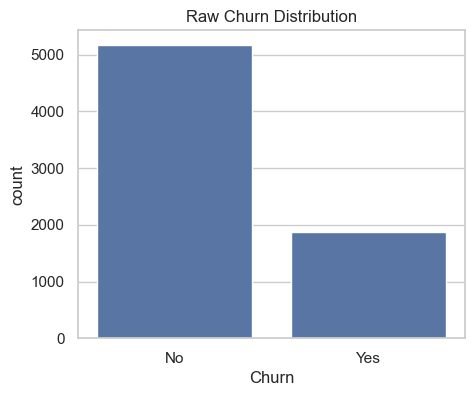

In [6]:
# Target distribution in raw data
target_counts = df_raw['Churn'].astype(str).str.strip().value_counts(dropna=False)
print(target_counts)

plt.figure(figsize=(5, 4))
sns.countplot(data=df_raw, x='Churn')
plt.title('Raw Churn Distribution')
plt.show()


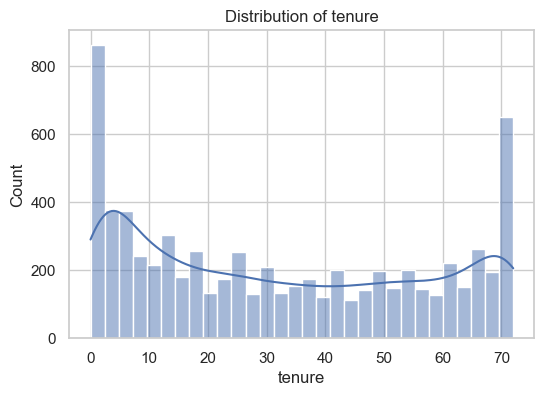

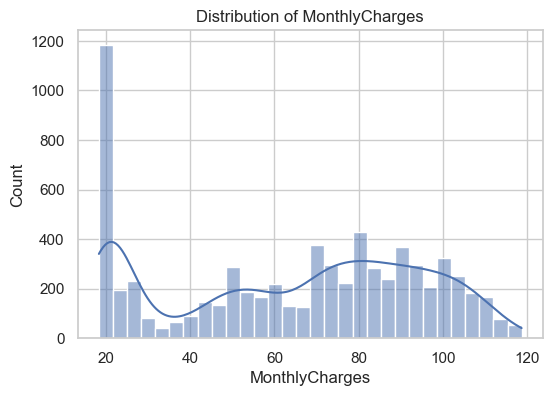

In [7]:
# Numeric preview for quick signal checks
numeric_cols_preview = ['tenure', 'MonthlyCharges']
for col in numeric_cols_preview:
    if col in df_raw.columns:
        plt.figure(figsize=(6, 4))
        sns.histplot(df_raw[col], kde=True, bins=30)
        plt.title(f'Distribution of {col}')
        plt.show()


## 3) Data Preparation
Clean fields, map target, define train/validation/test split, and create preprocessing pipeline.


In [8]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

df['Churn'] = (
    df['Churn'].astype(str).str.strip().str.lower()
    .map({'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0})
)

if df['Churn'].isna().any():
    raise ValueError('Unmapped values found in Churn column.')

print('Clean shape:', df.shape)
print('Null counts (top 10):')
print(df.isna().sum().sort_values(ascending=False).head(10))


Clean shape: (7043, 20)
Null counts (top 10):
TotalCharges        11
gender               0
SeniorCitizen        0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
dtype: int64


In [9]:
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape)
print('Validation shape:', X_val.shape)
print('Test shape:', X_test.shape)


Train shape: (4225, 19)
Validation shape: (1409, 19)
Test shape: (1409, 19)


In [10]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=['object']).columns.tolist()

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', ohe)]), categorical_cols),
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ],
    remainder='drop'
)

print('Categorical cols:', len(categorical_cols))
print('Numeric cols:', len(numeric_cols))


Categorical cols: 15
Numeric cols: 4


## 4) Model Exploration
Compare baseline and multiple candidate models.
Includes a modern boosting approach (`HistGradientBoostingClassifier`).


In [11]:
models = {
    'baseline_dummy': DummyClassifier(strategy='most_frequent'),
    'logistic_regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'random_forest': RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight='balanced_subsample',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'hist_gradient_boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

def collect_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_proba)),
    }

trained = {}
rows = []

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    y_val_pred = pipe.predict(X_val)
    if hasattr(pipe, 'predict_proba'):
        y_val_proba = pipe.predict_proba(X_val)[:, 1]
    else:
        decision = pipe.decision_function(X_val)
        y_val_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

    metrics = collect_metrics(y_val, y_val_pred, y_val_proba)
    rows.append({'model': name, **metrics})
    trained[name] = pipe

comparison_df = pd.DataFrame(rows).sort_values(['f1', 'roc_auc'], ascending=False).reset_index(drop=True)
comparison_df


,model,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,0.748758,0.516835,0.820856,0.634298,0.859332
1,random_forest,0.800568,0.620779,0.639037,0.629776,0.849066
2,hist_gradient_boosting,0.801278,0.650641,0.542781,0.591837,0.843695
3,baseline_dummy,0.734564,0.000000,0.000000,0.000000,0.500000


## 5) Final Evaluation on Test Set


Selected best model: logistic_regression
{'accuracy': 0.7416607523066004, 'precision': 0.5083892617449665, 'recall': 0.8101604278074866, 'f1': 0.6247422680412371, 'roc_auc': 0.8320519775762742}


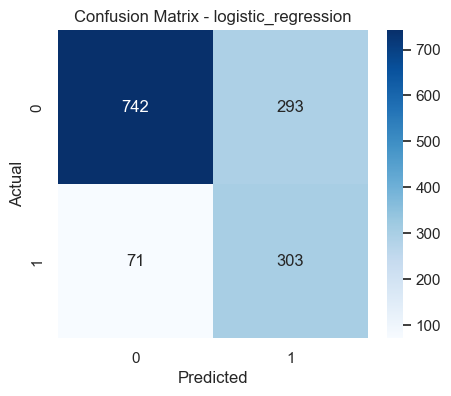

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.81      0.74      0.76      1409



In [12]:
best_model_name = comparison_df.iloc[0]['model']
best_model = trained[best_model_name]
print('Selected best model:', best_model_name)

y_test_pred = best_model.predict(X_test)
if hasattr(best_model, 'predict_proba'):
    y_test_proba = best_model.predict_proba(X_test)[:, 1]
else:
    decision = best_model.decision_function(X_test)
    y_test_proba = (decision - decision.min()) / (decision.max() - decision.min() + 1e-12)

test_metrics = {
    'accuracy': float(accuracy_score(y_test, y_test_pred)),
    'precision': float(precision_score(y_test, y_test_pred, zero_division=0)),
    'recall': float(recall_score(y_test, y_test_pred, zero_division=0)),
    'f1': float(f1_score(y_test, y_test_pred, zero_division=0)),
    'roc_auc': float(roc_auc_score(y_test, y_test_proba)),
}
print(test_metrics)

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, y_test_pred, zero_division=0))


## 6) Save Artifacts
These files support reproducibility and later reporting.


In [13]:
import joblib

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

comparison_path = artifacts_dir / 'model_comparison.csv'
metrics_path = artifacts_dir / 'metrics.json'
model_path = artifacts_dir / 'best_model.joblib'

comparison_df.to_csv(comparison_path, index=False)
payload = {
    'best_model': best_model_name,
    'validation_comparison': comparison_df.to_dict(orient='records'),
    'test_metrics': test_metrics,
}
metrics_path.write_text(json.dumps(payload, indent=2))
joblib.dump(best_model, model_path)

print('Saved:', comparison_path)
print('Saved:', metrics_path)
print('Saved:', model_path)


Saved: artifacts/model_comparison.csv
Saved: artifacts/metrics.json
Saved: artifacts/best_model.joblib


## 7) Next Actions
- Expand EDA visuals and leakage checks
- Add hyperparameter tuning for shortlisted models
- Add error analysis slices (e.g., by contract/internet type)
- Document at least one agent mistake found and corrected
